   label  pixel0  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  \
0      1       0       0       0       0       0       0       0       0   
1      0       0       0       0       0       0       0       0       0   
2      1       0       0       0       0       0       0       0       0   
3      4       0       0       0       0       0       0       0       0   
4      0       0       0       0       0       0       0       0       0   

   pixel8  ...  pixel774  pixel775  pixel776  pixel777  pixel778  pixel779  \
0       0  ...         0         0         0         0         0         0   
1       0  ...         0         0         0         0         0         0   
2       0  ...         0         0         0         0         0         0   
3       0  ...         0         0         0         0         0         0   
4       0  ...         0         0         0         0         0         0   

   pixel780  pixel781  pixel782  pixel783  
0         0         0         

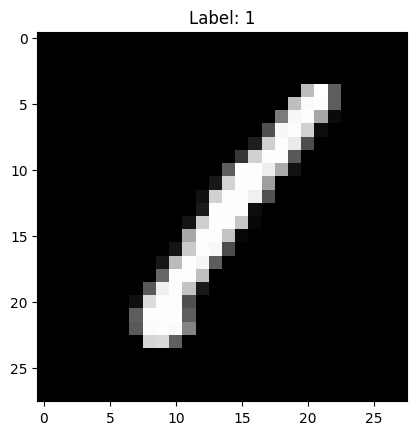

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from sklearn.model_selection import train_test_split

train = pd.read_csv('/kaggle/input/digit-recognizer/train.csv')
test = pd.read_csv('/kaggle/input/digit-recognizer/test.csv')

print(train.head())
print(f'Training data shape: {train.shape}')
print(f'Test data shape: {test.shape}')

sample = train.iloc[0, 1:].values.reshape(28, 28)
plt.imshow(sample, cmap='gray')
plt.title(f"Label: {train.iloc[0, 0]}")
plt.show()

/opt/conda/lib/python3.10/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8425 - loss: 0.5351 - val_accuracy: 0.9525 - val_loss: 0.1614
Epoch 2/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9628 - loss: 0.1284 - val_accuracy: 0.9631 - val_loss: 0.1226
Epoch 3/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9750 - loss: 0.0801 - val_accuracy: 0.9676 - val_loss: 0.1116
Epoch 4/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9819 - loss: 0.0604 - val_accuracy: 0.9692 - val_loss: 0.0999
Epoch 5/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9849 - loss: 0.0474 - val_accuracy: 0.9688 - val_loss: 0.1165
Epoch 6/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9892 - loss: 0.0353 - val_accuracy: 0.9707 - val_loss: 0.1122
Epoch 7/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9925 - loss: 0.0250 - val_accuracy: 0.9604 - val_loss: 0.1386
Epoch 8/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9924 - loss: 0.0230 - 

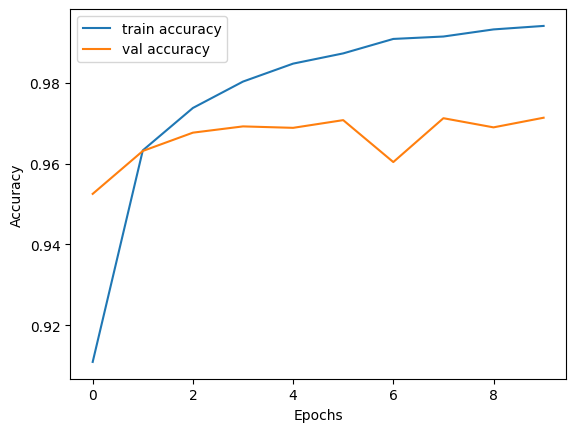

875/875 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


In [2]:
X = train.drop('label', axis=1).values  
y = train['label'].values  # Labels

X = X / 255.0
test = test.values / 255.0  

X = X.reshape(-1, 28, 28)
test = test.reshape(-1, 28, 28)  

y = tf.keras.utils.to_categorical(y, 10)

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

model = Sequential([
    Flatten(input_shape=(28, 28)),  # Flatten input images
    Dense(128, activation='relu'),  # First hidden layer with 128 neurons and ReLU activation
    Dense(64, activation='relu'),   # Second hidden layer with 64 neurons and ReLU activation
    Dense(10, activation='softmax') # Output layer with 10 neurons for classification
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history = model.fit(X_train, y_train, epochs=10, validation_data=(X_val, y_val))

plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

predictions = model.predict(test)
predicted_labels = predictions.argmax(axis=1)

submission = pd.DataFrame({'ImageId': list(range(1, len(predicted_labels) + 1)), 'Label': predicted_labels})
submission.to_csv('sania_submission3.csv', index=False)

In [3]:
# Make predictions on the test data
predictions = model.predict(test)  # Assuming `test` is your normalized test data reshaped correctly
predicted_labels = predictions.argmax(axis=1)  # Get the predicted label for each sample

# Create the submission DataFrame
submission = pd.DataFrame({
    'ImageId': list(range(1, len(predicted_labels) + 1)),  # ImageId should start from 1
    'Label': predicted_labels
})

# Save the submission file
submission.to_csv('sania_submission3.csv', index=False)

# Display the first few rows of the submission file to verify
print(submission.head())

875/875 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
   ImageId  Label
0        1      2
1        2      0
2        3      9
3        4      9
4        5      3
